In [81]:
import wfdb
import numpy as np
from sklearn.model_selection import train_test_split

window = 93


def encode_label(l):

    if l in ['N','L','R','e','j']:
        return 0   # Normal

    elif l in ['A','a','J','S']:
        return 1   # Supraventricular ectopic

    elif l in ['V','E']:
        return 2   # Ventricular ectopic

    elif l in ['F']:
        return 3   # Fusion beat

    elif l in ['/', 'f', 'Q']:
        return 4   # Unknown / paced

    return None

EXCLUDED_RECORDS = {"102", "104", "107", "217"}

def normalize(X):
    return (X - X.mean(axis=1, keepdims=True)) / X.std(axis=1, keepdims=True)


def extract_beats(record_list, folder):

    beats = []
    labels = []

    for r in record_list:
        if r in EXCLUDED_RECORDS:
            continue

        path = f"{folder}/{r}"

        record = wfdb.rdrecord(path)
        annotation = wfdb.rdann(path, 'atr')

        signal = record.p_signal[:, 0]
        peaks = annotation.sample
        ann = annotation.symbol

        for p, l in zip(peaks, ann):

            encoded = encode_label(l)

            if encoded is None:
                continue

            if p-window < 0 or p+window+1 > len(signal):
                continue

            beat = signal[p-window:p+window+1]

            beats.append(beat)
            labels.append(encoded)

    return np.array(beats), np.array(labels)



In [106]:
class InterPatientDataset:

    def __init__(self, records, folder, test_size=0.2, random_state=42):

        train_records, test_records = train_test_split(
            records,
            test_size=test_size,
            random_state=random_state
        )

        X_train, y_train = extract_beats(train_records, folder)
        X_test, y_test = extract_beats(test_records, folder)

        self.X_train = X_train
        self.X_test = X_test


        self.X_train = (X_train - X_train.mean(axis=1)) / X_train.mean(axis=1)
        self.X_test = (X_test - X_test.std(axis=1)) / X_test.std(axis=1)

        self.y_train = y_train
        self.y_test = y_test

        print("Inter-patient split")
        print("Train shape:", self.X_train.shape)
        print("Test shape:", self.X_test.shape)

class IntraPatientDataset:
    def __init__(self, records, folder, test_size=0.2, random_state=42):

        X, y = extract_beats(records, folder)

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=test_size,
            random_state=random_state
        )

        self.X_train = X_train
        self.X_test = X_test
        

        
        self.X_train = (X_train - X_train.mean(axis=1, keepdims=True)) / X_train.std(axis=1, keepdims=True)
        self.X_test = (X_test - X_test.mean(axis=1, keepdims=True)) / X_test.std(axis=1, keepdims=True)


        self.y_train = y_train
        self.y_test = y_test

        print("Intra-patient split")
        print("Train shape:", self.X_train.shape)
        print("Test shape:", self.X_test.shape)

In [107]:
import os
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

folder = "mit-bih-arrhythmia-database-1.0.0"

records = [f.replace(".hea","")
           for f in os.listdir(folder)
           if f.endswith(".hea")]

ds = IntraPatientDataset(records, folder)
X_train, X_test, y_train, y_test = ds.X_train, ds.X_test, ds.y_train, ds.y_test

def preprocess_ecg(X, y, apply_noise=False):

    # ----------------------------
    # remove NaNs
    # ----------------------------
    mask = ~np.isnan(X).any(axis=1)
    X = X[mask]
    y = y[mask]

    # ----------------------------
    # normalize signal
    # ----------------------------
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # ----------------------------
    # peak enhancement (simple version)
    # ----------------------------
    X = X / np.max(np.abs(X), axis=1, keepdims=True)

    # ----------------------------
    # optional Gaussian noise
    # ----------------------------
    if apply_noise:
        noise = np.random.normal(0, 0.05, X.shape)
        X = X + noise

    # ----------------------------
    # SMOTE class balancing
    # ----------------------------
    smote = SMOTE()
    X, y = smote.fit_resample(X, y)

    # ----------------------------
    # PCA dimensional reduction
    # ----------------------------

    return X, y

def percent_trained(X_train, y_train, percent_train):
    if percent_train < 100.0:
        frac = percent_train / 100.0
    
        X_train, _, y_train, _ = train_test_split(
            X_train,
            y_train,
            train_size=frac,
            stratify=y_train,
        )
    
        print(f"Using {len(y_train)} labeled training beats ({percent_train}%)")

        return X_train, y_train
    return X_train, y_train

X_train, y_train = percent_trained(X_train, y_train, 100)


# X_train, y_train = preprocess_ecg(X_train, y_train)
# X_test, y_test = preprocess_ecg(X_test, y_test)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)




Intra-patient split
Train shape: (80566, 187)
Test shape: (20142, 187)


In [108]:
import numpy as np

train_counts = np.bincount(y_train)
test_counts = np.bincount(y_test)

print("\nTrain percentages:")
for i in range(5):
    if i >= len(train_counts):
        continue
    print(f"i = {i}:", train_counts[i] / len(y_train))

print("\nTest percentages:")
for i in range(5):
    print(f"i = {i}:", test_counts[i] / len(y_test))




Train percentages:
i = 0: 0.8956135342452151
i = 1: 0.02746816274855398
i = 2: 0.06896209319067596
i = 3: 0.007794851426159918
i = 4: 0.00016135838939503017

Test percentages:
i = 0: 0.8909740840035746
i = 1: 0.028199781550987985
i = 2: 0.07208817396484957
i = 3: 0.008638665475126601
i = 4: 9.92950054612253e-05


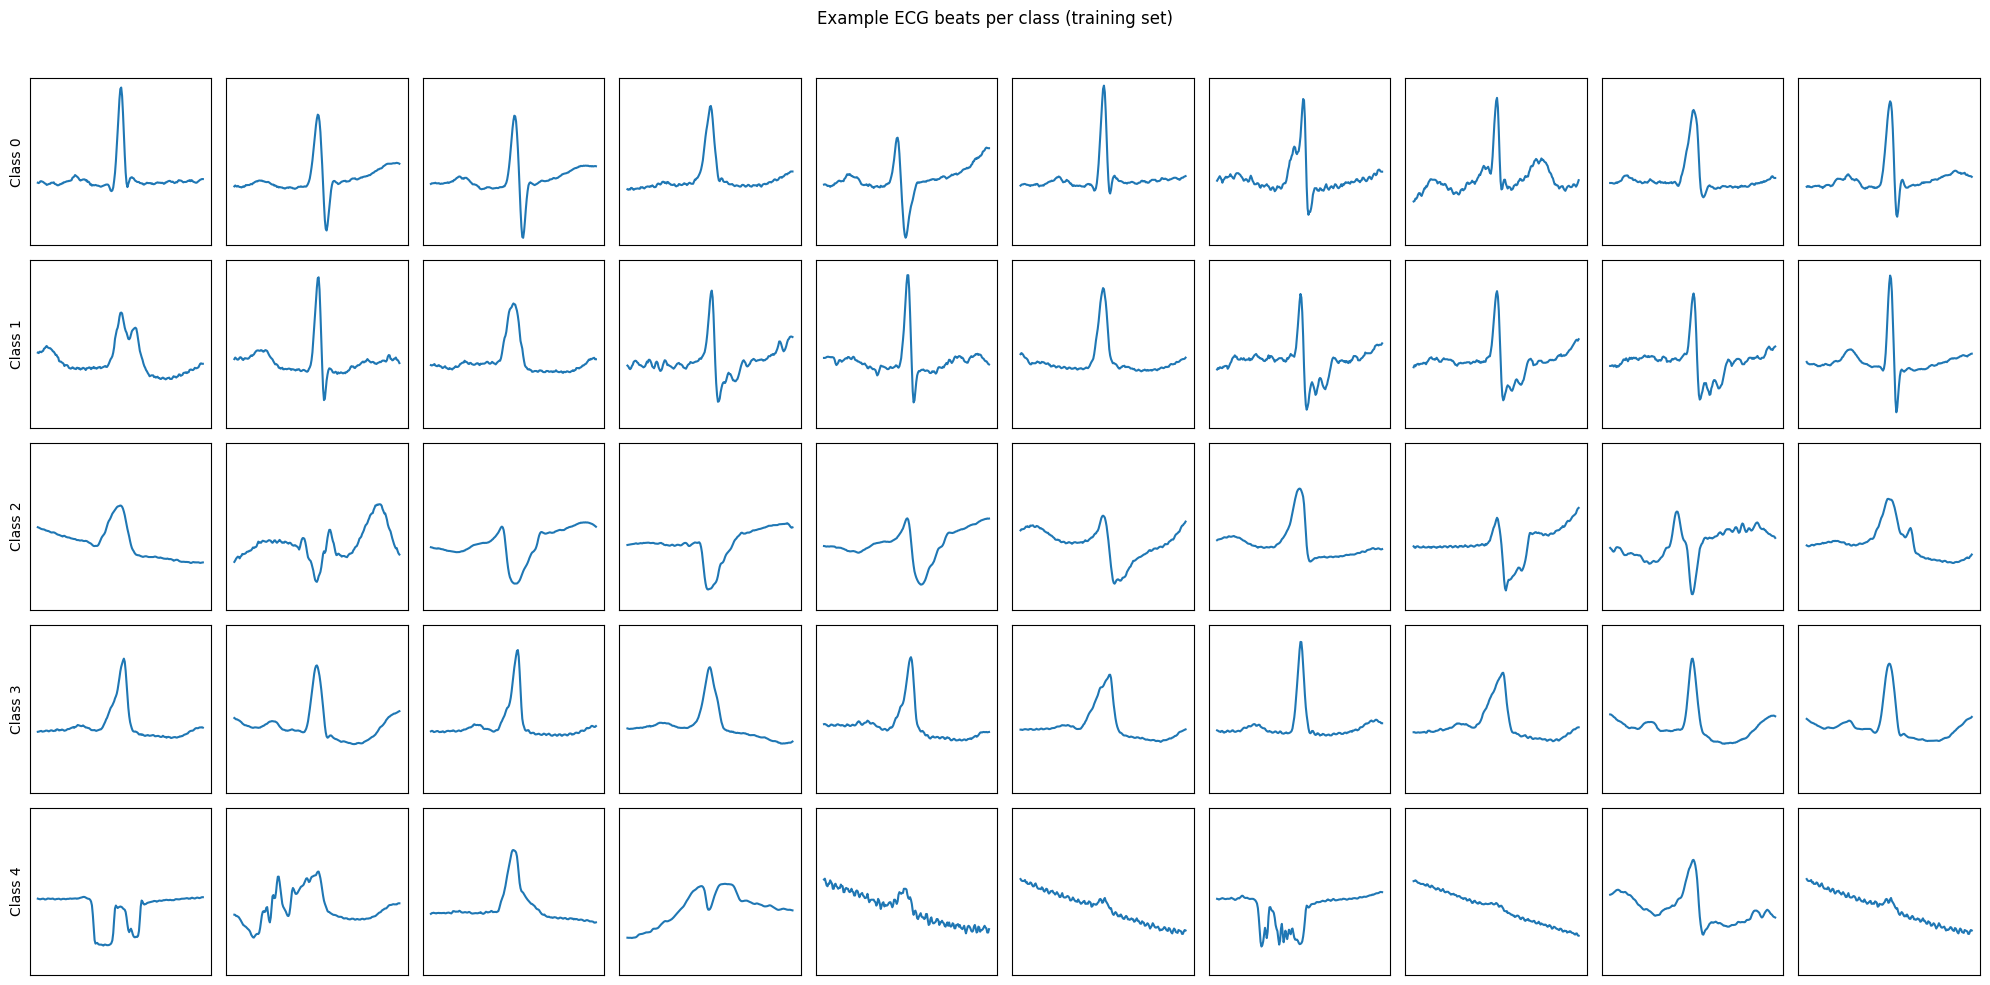

In [109]:
import matplotlib.pyplot as plt

# Plot 10 example beats per class from the training set
num_classes = 5
examples_per_class = 10

fig, axes = plt.subplots(num_classes, examples_per_class, figsize=(2 * examples_per_class, 2 * num_classes), sharex=True, sharey=True)

# Ensure axes is 2D even if num_classes or examples_per_class is 1
if num_classes == 1:
    axes = axes[None, :]
if examples_per_class == 1:
    axes = axes[:, None]

for cls in range(num_classes):
    # indices of this class in training labels
    cls_indices = np.where(y_train == cls)[0]

    if len(cls_indices) == 0:
        continue

    # choose up to `examples_per_class` examples
    selected = cls_indices[np.random.randint(0, len(cls_indices), (examples_per_class,))]

    for j, idx in enumerate(selected):
        ax = axes[cls, j]
        ax.plot(X_train[idx])
        ax.set_xticks([])
        ax.set_yticks([])
        if j == 0:
            ax.set_ylabel(f"Class {cls}")

# Add a global title and tighten layout
plt.suptitle("Example ECG beats per class (training set)")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Logistic Regression

In [110]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, accuracy_score
from sklearn.metrics import confusion_matrix

model = LogisticRegression(
    multi_class="ovr",
    solver="lbfgs",
    class_weight="balanced",
    max_iter=200
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)


acc = balanced_accuracy_score(y_test, y_pred)
print("Balanced accuracy:", acc)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)


print(confusion_matrix(y_test, y_pred))

/Users/viriyadhika/Documents/5.UofT/Courses/CSC2515/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/viriyadhika/Documents/5.UofT/Courses/CSC2515/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/viriyadhika/Documents/5.UofT/Courses/CSC2515/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/viriyadhika/Documents/5.UofT/Courses/CSC2515/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + inter

Balanced accuracy: 0.602452830016207
Accuracy: 0.8068712143779168
[[14606   829  1773   686    52]
 [  176   361    18    11     2]
 [   73    74  1151   115    39]
 [   25     2    13   134     0]
 [    0     0     2     0     0]]


/Users/viriyadhika/Documents/5.UofT/Courses/CSC2515/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/viriyadhika/Documents/5.UofT/Courses/CSC2515/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/viriyadhika/Documents/5.UofT/Courses/CSC2515/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/viriyadhika/Documents/5.UofT/Courses/CSC2515/.venv/lib/python3.9/site-packag

# KNN

In [111]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, accuracy_score

for i in [2, 5, 10]:
    
    knn = KNeighborsClassifier(
        n_neighbors=i,
        metric="euclidean"
    )
    knn.fit(X_train, y_train)

    preds = knn.predict(X_test)

    bal_acc = balanced_accuracy_score(y_test, preds)
    acc = accuracy_score(y_test, preds)

    print("Balanced Accuracy:", bal_acc)
    print("Accuracy:", acc)
    print(confusion_matrix(y_test, preds))

Balanced Accuracy: 0.706452962641474
Accuracy: 0.9885314268692285
[[17909    21    12     3     1]
 [   93   474     1     0     0]
 [   41     6  1400     5     0]
 [   30     0    16   128     0]
 [    2     0     0     0     0]]
Balanced Accuracy: 0.715631614808873
Accuracy: 0.9885810743719591
[[17894    27    20     4     1]
 [   84   479     5     0     0]
 [   33     4  1405    10     0]
 [   31     0     9   134     0]
 [    2     0     0     0     0]]
Balanced Accuracy: 0.6976115511911064
Accuracy: 0.9871412967927713
[[17899    21    22     4     0]
 [  103   459     6     0     0]
 [   43     2  1400     7     0]
 [   35     0    14   125     0]
 [    2     0     0     0     0]]


In [54]:
spec = torch.stft(
    torch.tensor(X_train_sub),
    n_fft=64,
    hop_length=16,
    return_complex=True
)

spec_mag = torch.abs(spec)

spec_mag.shape, X_train_sub.shape

(torch.Size([805, 33, 12]), (805, 187))

# Single Layer MLP

In [7]:
import torch
import torch.nn as nn

class SingleLayerMLP(nn.Module):

    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()

        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x


0 1.6180895566940308
10 1.0751208066940308
20 0.8754276037216187
30 0.7682383060455322
40 0.6989848613739014
50 0.6484290957450867
60 0.6079893112182617
70 0.5729889273643494
80 0.5404719114303589
90 0.5101960301399231
100 0.48238155245780945
110 0.45735669136047363
120 0.43484556674957275
130 0.4142601788043976
140 0.39549821615219116
150 0.37833964824676514
160 0.36252471804618835
170 0.3479326069355011
180 0.33459827303886414
190 0.32228884100914
200 0.31092068552970886
210 0.3003373146057129
220 0.29041028022766113
230 0.2814076840877533
240 0.27319973707199097
250 0.26568666100502014
260 0.2587822377681732
270 0.2523496747016907
280 0.246317058801651
290 0.2406490445137024
300 0.23524914681911469
310 0.2301332801580429
320 0.22526179254055023
330 0.22074908018112183
340 0.21649889647960663
350 0.21247906982898712
360 0.20864665508270264
370 0.20499686896800995
380 0.2015165537595749
390 0.1981913447380066
[[10288  2337  4132   318   817]
 [   43    18     1     7     4]
 [   48   

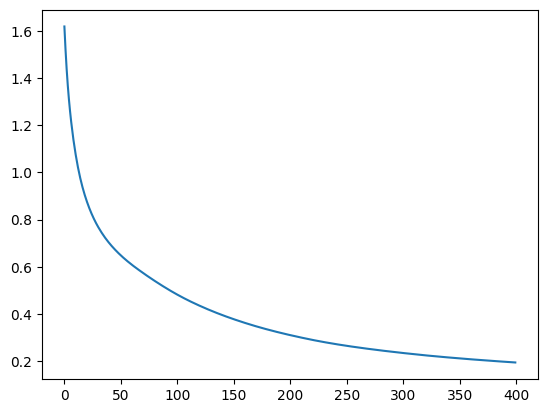

In [8]:
from torch import nn
import matplotlib.pyplot as plt
import numpy as np
import torch

model = SingleLayerMLP(
    input_size=200,
    hidden_size=64,
    num_classes=5
)

# compute balanced weights
class_counts = np.bincount(y_train)
weights = len(y_train) / (len(class_counts) * class_counts)
weights = torch.tensor(weights, dtype=torch.float32)

criterion = nn.CrossEntropyLoss(weight=weights)

# optimizer = torch.optim.LBFGS(model.parameters())

# epochs = 2
# losses = []

# for epoch in range(epochs):

#     def closure():
#         optimizer.zero_grad()

#         outputs = model(X_train_t)
#         loss = criterion(outputs, y_train_t)

#         loss.backward()
#         losses.append(loss.item())

#         return loss

#     loss = optimizer.step(closure)

#     print("Epoch:", epoch, "Loss:", loss.item())

# plt.plot(losses)


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 400

losses = []
for epoch in range(epochs):

    optimizer.zero_grad()

    outputs = model(X_train_t)

    loss = criterion(outputs, y_train_t)

    loss.backward()
    losses.append(loss.item())
    optimizer.step()

    if epoch % 10 == 0:
        print(epoch, loss.item())

plt.plot(losses)

with torch.no_grad():

    outputs = model(X_test_t)

    preds = torch.argmax(outputs, dim=1)

    y_true = y_test_t.cpu().numpy()
    y_pred = preds.cpu().numpy()

    bal_acc = balanced_accuracy_score(y_true, y_pred)

    print(confusion_matrix(y_true, y_pred))

print("Balanced Accuracy:", bal_acc)

# CNN

In [63]:
X_train_cnn = X_train_t.unsqueeze(1)  # (N,1,200)
X_test_cnn = X_test_t.unsqueeze(1)

In [64]:
from torch.nn import functional as F

class ECG_CNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()

        self.conv1 = nn.Conv1d(1, 16, kernel_size=7, padding=3)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=5, padding=2)
        self.conv3 = nn.Conv1d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool1d(2)

        self.fc1 = nn.Linear(64 * 25, 128)
        self.fc2 = nn.Linear(128, num_classes)

        self.dropout = nn.Dropout(0.3)

    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))  # 200 → 100
        x = self.pool(F.relu(self.conv2(x)))  # 100 → 50
        x = self.pool(F.relu(self.conv3(x)))  # 50 → 25

        x = x.view(x.size(0), -1)

        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

In [65]:
model = ECG_CNN()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

criterion = nn.CrossEntropyLoss(weight=weights)

epochs = 50
batch_size = 256

In [66]:
model = ECG_CNN()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

criterion = nn.CrossEntropyLoss(weight=weights)

epochs = 50
batch_size = 256

for epoch in range(epochs):

    perm = torch.randperm(X_train_cnn.size(0))

    for i in range(0, len(perm), batch_size):

        idx = perm[i:i+batch_size]

        xb = X_train_cnn[idx]
        yb = y_train_t[idx]

        optimizer.zero_grad()

        outputs = model(xb)

        loss = criterion(outputs, yb)

        loss.backward()

        optimizer.step()

    if epoch % 10 == 0:
        print(epoch, loss.item())

with torch.no_grad():

    preds = torch.argmax(model(X_test_cnn), dim=1)

    bal_acc = balanced_accuracy_score(
        y_test_t.numpy(),
        preds.numpy()
    )
    print(confusion_matrix(y_test, preds))

print("Balanced accuracy:", bal_acc)

KeyboardInterrupt: 

# RFF MLP & RFF GLM

In [9]:
import torch
import torch.nn as nn
import math

class RFFLayer(nn.Module):

    def __init__(self, input_dim, rff_dim, gamma=0.1):
        super().__init__()

        self.W = nn.Parameter(
            torch.randn(input_dim, rff_dim) * math.sqrt(2 * gamma),
            requires_grad=False
        )

        self.b = nn.Parameter(
            2 * math.pi * torch.rand(rff_dim),
            requires_grad=False
        )

        self.scale = math.sqrt(2.0 / rff_dim)

    def forward(self, x):

        projection = x @ self.W + self.b

        return self.scale * torch.cos(projection)
    
class RFF_MLP(nn.Module):

    def __init__(self, input_size, rff_dim, hidden_size, num_classes):
        super().__init__()

        self.rff = RFFLayer(input_size, rff_dim)

        self.fc1 = nn.Linear(rff_dim, hidden_size)
        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):

        x = self.rff(x)

        x = self.fc1(x)
        x = self.relu(x)

        x = self.fc2(x)

        return x
    

class RFF_GLM(nn.Module):

    def __init__(self, input_size, rff_dim, num_classes):
        super().__init__()

        self.rff = RFFLayer(input_size, rff_dim)
        self.linear = nn.Linear(rff_dim, num_classes)

    def forward(self, x):

        x = self.rff(x)
        return self.linear(x)

/Users/viriyadhika/Documents/5.UofT/Courses/CSC2515/.venv/lib/python3.9/site-packages/torch/optim/lbfgs.py:457: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  loss = float(closure())


Epoch: 0 Loss: 1.6113938093185425
Epoch: 1 Loss: 0.706725001335144
[[6489 2292 5007 1472 2632]
 [  35   13   13    5    7]
 [ 348  114  903  554  520]
 [  66   31  141  100   44]
 [ 288  257   77   45 1423]]
Balanced Accuracy: 0.3707266598374108


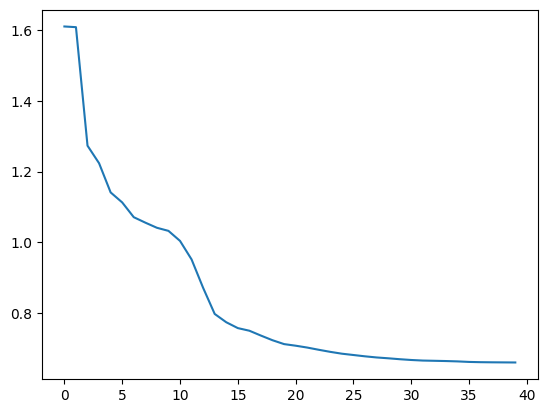

In [10]:
import torch.optim as optim
from torch import nn

model = RFF_GLM(
    input_size=200,
    rff_dim=500,
    num_classes=5
)

# compute balanced weights
class_counts = np.bincount(y_train)
weights = len(y_train) / (len(class_counts) * class_counts)
weights = torch.tensor(weights, dtype=torch.float32)

criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.LBFGS(model.parameters())


epochs = 2

losses = []
for epoch in range(epochs):

    def closure():
        optimizer.zero_grad()

        outputs = model(X_train_t)
        loss = criterion(outputs, y_train_t)

        loss.backward()
        losses.append(loss.item())

        return loss

    loss = optimizer.step(closure)

    print("Epoch:", epoch, "Loss:", loss.item())

plt.plot(losses)

with torch.no_grad():

    outputs = model(X_test_t)

    preds = torch.argmax(outputs, dim=1)

    y_true = y_test_t.cpu().numpy()
    y_pred = preds.cpu().numpy()

    bal_acc = balanced_accuracy_score(y_true, y_pred)

    print(confusion_matrix(y_true, y_pred))

print("Balanced Accuracy:", bal_acc)

0 1.626570463180542
10 1.611749291419983
20 1.5917283296585083
30 1.5691498517990112
40 1.5448076725006104
50 1.5191001892089844
60 1.4933568239212036
70 1.4684094190597534
80 1.4446253776550293
90 1.422089695930481
100 1.4007056951522827
110 1.3803277015686035
120 1.360741138458252
130 1.3417317867279053
140 1.3231453895568848
150 1.304831862449646
160 1.2866932153701782
170 1.2686351537704468
180 1.2506076097488403
190 1.232592225074768
200 1.21455979347229
210 1.196560263633728
220 1.1786640882492065
230 1.1608976125717163
240 1.1433279514312744
250 1.1259950399398804
260 1.1089520454406738
270 1.092220664024353
280 1.0758285522460938
290 1.0598031282424927
300 1.0441645383834839
310 1.0289188623428345
320 1.0140835046768188
330 0.9996504783630371
340 0.9856394529342651
350 0.9720456600189209
360 0.9588583707809448
370 0.9460920095443726
380 0.9337674379348755
390 0.9218659996986389
[[6964 1501 2844 2659 3924]
 [  17   16   13   16   11]
 [ 399   93  725  778  444]
 [ 111   11  104 

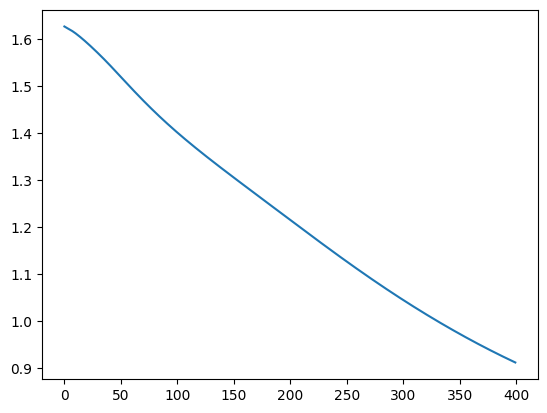

In [11]:
import torch.optim as optim
from torch import nn

model = RFF_MLP(
    input_size=200,
    rff_dim=500,
    hidden_size=8,
    num_classes=5
)

# compute balanced weights
class_counts = np.bincount(y_train)
weights = len(y_train) / (len(class_counts) * class_counts)
weights = torch.tensor(weights, dtype=torch.float32)

criterion = nn.CrossEntropyLoss(weight=weights)


# LBFGS
# optimizer = torch.optim.LBFGS(model.parameters(), lr=0.4)

# epochs = 2

# losses = []
# for epoch in range(epochs):

#     def closure():
#         optimizer.zero_grad()

#         outputs = model(X_train_t)
#         loss = criterion(outputs, y_train_t)

#         loss.backward()
#         losses.append(loss.item())

#         return loss

#     loss = optimizer.step(closure)

#     print("Epoch:", epoch, "Loss:", loss.item())

# plt.plot(losses)

# Adam Opt
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 400

losses = []
for epoch in range(epochs):

    optimizer.zero_grad()

    outputs = model(X_train_t)

    loss = criterion(outputs, y_train_t)

    loss.backward()
    losses.append(loss.item())
    optimizer.step()

    if epoch % 10 == 0:
        print(epoch, loss.item())

plt.plot(losses)

with torch.no_grad():

    outputs = model(X_test_t)

    preds = torch.argmax(outputs, dim=1)

    y_true = y_test_t.cpu().numpy()
    y_pred = preds.cpu().numpy()

    bal_acc = balanced_accuracy_score(y_true, y_pred)

    print(confusion_matrix(y_test, preds))
    
print("Balanced Accuracy:", bal_acc)

# GLM

In [12]:
from sklearn.kernel_approximation import RBFSampler

rbf = RBFSampler(
    gamma=0.1,
    n_components=500,
    random_state=42
)

X_train_rff = rbf.fit_transform(X_train)
X_test_rff = rbf.transform(X_test)

glm_rff = LogisticRegression(
    multi_class="ovr",
    solver="lbfgs",
    class_weight="balanced",
    max_iter=200
)

glm_rff.fit(X_train_rff, y_train)

preds = glm_rff.predict(X_test_rff)

print("RFF GLM accuracy:", balanced_accuracy_score(y_test, preds))
confusion_matrix(y_test, preds)

/Users/viriyadhika/Documents/5.UofT/Courses/CSC2515/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/viriyadhika/Documents/5.UofT/Courses/CSC2515/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/viriyadhika/Documents/5.UofT/Courses/CSC2515/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/viriyadhika/Documents/5.UofT/Courses/CSC2515/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/viriyadhika/Documents/5.UofT/Courses/CSC2515/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/viriyadhika/Documents/5.UofT/Courses/CSC2515/.venv/lib/python3.9/site-packages/sklearn/util

RFF GLM accuracy: 0.3209053371179101


/Users/viriyadhika/Documents/5.UofT/Courses/CSC2515/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/viriyadhika/Documents/5.UofT/Courses/CSC2515/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/viriyadhika/Documents/5.UofT/Courses/CSC2515/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


array([[6159, 1326, 4987, 1226, 4194],
       [  20,   12,   20,    6,   15],
       [ 572,  157,  954,  247,  509],
       [  94,   37,   85,   36,  130],
       [  31,   36,  160,  587, 1276]])

# VAE

In [13]:
class VAE(nn.Module):

    def __init__(self, input_dim=200, hidden_dim=64, latent_dim=16):
        super().__init__()

        # encoder
        self.enc1 = nn.Linear(input_dim, hidden_dim)
        self.enc2 = nn.Linear(hidden_dim, hidden_dim)

        self.mu = nn.Linear(hidden_dim, latent_dim)
        self.logvar = nn.Linear(hidden_dim, latent_dim)

        # decoder
        self.dec1 = nn.Linear(latent_dim, hidden_dim)
        self.dec2 = nn.Linear(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = torch.relu(self.enc1(x))
        h = torch.relu(self.enc2(h))
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.dec1(z))
        h = torch.relu(self.dec2(h))
        return self.out(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

In [14]:
def vae_loss(x, recon, mu, logvar):
    recon_loss = nn.functional.mse_loss(recon, x)

    kl = -0.5 * torch.mean(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return recon_loss + 0.1 * kl

0 1.0169988870620728
10 0.9986749887466431
20 0.8817460536956787
30 0.6080700755119324
40 0.4810653030872345
50 0.443891704082489
60 0.41409003734588623
70 0.3598009943962097
80 0.32494083046913147
90 0.3016965687274933
100 0.2711122930049896
110 0.250744104385376
120 0.2413838654756546
130 0.23469454050064087
140 0.2282111644744873
150 0.2198161482810974
160 0.20828652381896973
170 0.19761872291564941
180 0.18844397366046906
190 0.1804809272289276
200 0.1733679473400116
210 0.16771122813224792
220 0.16329333186149597
230 0.15992975234985352
240 0.15661495923995972
250 0.15351983904838562
260 0.15092463791370392
270 0.148035928606987
280 0.14513513445854187
290 0.14283710718154907
300 0.14049217104911804
310 0.13835135102272034
320 0.13640998303890228
330 0.1347050964832306
340 0.1328955590724945
350 0.13119283318519592
360 0.13012024760246277
370 0.12841808795928955
380 0.1270093321800232
390 0.1255827248096466


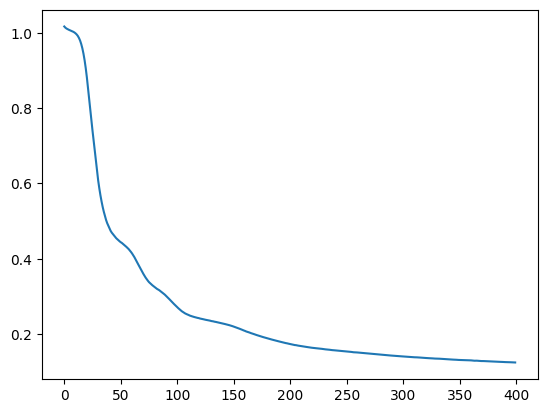

In [15]:
model = VAE()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 400

losses = []
for epoch in range(epochs):

    optimizer.zero_grad()

    recon, mu, logvar = model(X_train_t)

    loss = vae_loss(X_train_t, recon, mu, logvar)

    loss.backward()
    optimizer.step()

    
    if epoch % 10 == 0:
        print(epoch, loss.item())
    losses.append(loss.item())

plt.plot(losses)


with torch.no_grad():

    mu_train, _ = model.encode(X_train_t)
    mu_test, _ = model.encode(X_test_t)

Z_train = mu_train.numpy()
Z_test = mu_test.numpy()

In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(Z_train, y_train)

preds = knn.predict(Z_test)

print("Latent KNN accuracy:", balanced_accuracy_score(y_test, preds))
print(confusion_matrix(y_test, preds))

Latent KNN accuracy: 0.4726547966273261
[[15693   743  1424     3    29]
 [   66     7     0     0     0]
 [  226    16  2067    15   115]
 [  192     4   184     1     1]
 [   26   922    13     0  1129]]


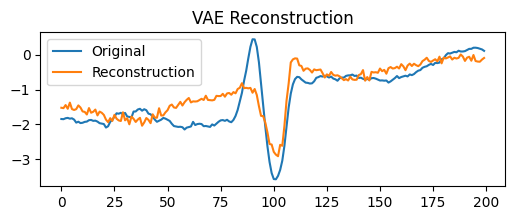

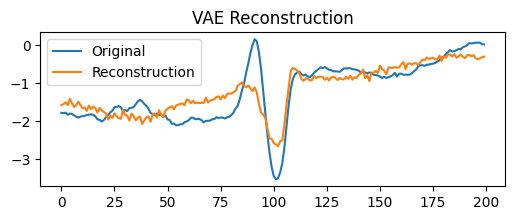

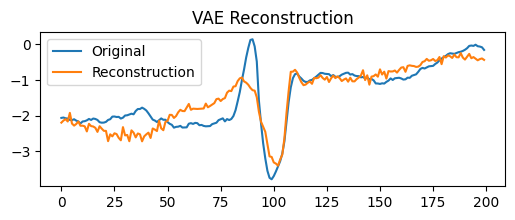

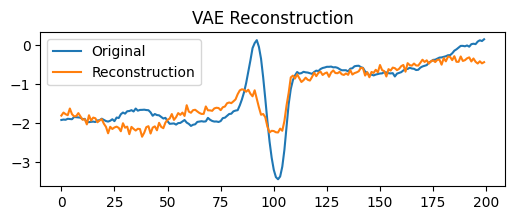

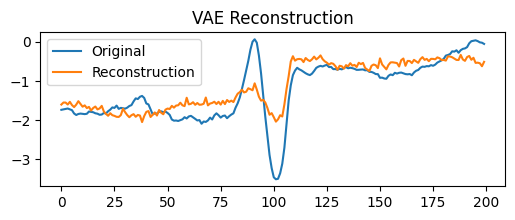

In [17]:
import matplotlib.pyplot as plt
with torch.no_grad():

    subset = X_test_t[:5]
    recon, _, _ = model(subset)

    for i in range(len(subset)):

        plt.figure(figsize=(6,2))

        plt.plot(subset[i].cpu(), label="Original")
        plt.plot(recon[i].cpu(), label="Reconstruction")

        plt.legend()
        plt.title("VAE Reconstruction")
        plt.show()

# RFF VAE

In [18]:
import torch.nn.functional as F

class RFFVAE(nn.Module):

    def __init__(self, input_dim=200, rff_dim=128, hidden_dim=64, latent_dim=16, gamma=0.1):
        super().__init__()

        self.rff = RFFLayer(input_dim, rff_dim, gamma=gamma)

        # encoder on top of RFF features
        self.enc1 = nn.Linear(rff_dim, hidden_dim)
        self.enc2 = nn.Linear(hidden_dim, hidden_dim)

        self.mu = nn.Linear(hidden_dim, latent_dim)
        self.logvar = nn.Linear(hidden_dim, latent_dim)

        # decoder reconstructs original ECG signal
        self.dec1 = nn.Linear(latent_dim, hidden_dim)
        self.dec2 = nn.Linear(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = self.rff(x)
        h = torch.relu(self.enc1(h))
        h = torch.relu(self.enc2(h))
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.dec1(z))
        h = torch.relu(self.dec2(h))
        return self.out(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar
    

def vae_loss(x, recon, mu, logvar, beta=0.1):
    recon_loss = F.mse_loss(recon, x, reduction="mean")

    kl = -0.5 * torch.mean(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return recon_loss + beta * kl, recon_loss, kl

In [19]:
model = RFFVAE()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 200
losses = []
recon_losses = []
kl_losses = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    recon, mu, logvar = model(X_train_t)

    loss, recon_loss, kl_loss = vae_loss(X_train_t, recon, mu, logvar, beta=0.1)

    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    recon_losses.append(recon_loss.item())
    kl_losses.append(kl_loss.item())
    if epoch % 10 == 0:
        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Loss: {loss.item():.4f} | "
            f"Recon: {recon_loss.item():.4f} | "
            f"KL: {kl_loss.item():.4f}"
        )

Epoch 1/200 | Loss: 1.0181 | Recon: 1.0176 | KL: 0.0053
Epoch 11/200 | Loss: 1.0055 | Recon: 1.0052 | KL: 0.0031
Epoch 21/200 | Loss: 1.0025 | Recon: 1.0024 | KL: 0.0014
Epoch 31/200 | Loss: 1.0014 | Recon: 1.0013 | KL: 0.0006
Epoch 41/200 | Loss: 1.0006 | Recon: 1.0005 | KL: 0.0008
Epoch 51/200 | Loss: 0.9975 | Recon: 0.9971 | KL: 0.0035
Epoch 61/200 | Loss: 0.9700 | Recon: 0.9678 | KL: 0.0214
Epoch 71/200 | Loss: 0.8776 | Recon: 0.8674 | KL: 0.1018
Epoch 81/200 | Loss: 0.8071 | Recon: 0.7882 | KL: 0.1890
Epoch 91/200 | Loss: 0.7658 | Recon: 0.7427 | KL: 0.2304
Epoch 101/200 | Loss: 0.7349 | Recon: 0.7132 | KL: 0.2165
Epoch 111/200 | Loss: 0.7093 | Recon: 0.6873 | KL: 0.2199
Epoch 121/200 | Loss: 0.6864 | Recon: 0.6625 | KL: 0.2395
Epoch 131/200 | Loss: 0.6649 | Recon: 0.6396 | KL: 0.2528
Epoch 141/200 | Loss: 0.6467 | Recon: 0.6203 | KL: 0.2639
Epoch 151/200 | Loss: 0.6321 | Recon: 0.6046 | KL: 0.2750
Epoch 161/200 | Loss: 0.6202 | Recon: 0.5925 | KL: 0.2777
Epoch 171/200 | Loss: 0.6

In [20]:
with torch.no_grad():
    mu_train, _ = model.encode(X_train_t)
    mu_test, _ = model.encode(X_test_t)

Z_train = mu_train.cpu().numpy()
Z_test = mu_test.cpu().numpy()

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(Z_train, y_train)

preds = knn.predict(Z_test)

print("Balanced accuracy:", balanced_accuracy_score(y_test, preds))
print(confusion_matrix(y_test, preds))

Balanced accuracy: 0.2017337359254428
[[16713    87   467     9   616]
 [   68     0     3     0     2]
 [ 2245     4    78     3   109]
 [  349     0    16     0    17]
 [ 1942     3    55     1    89]]


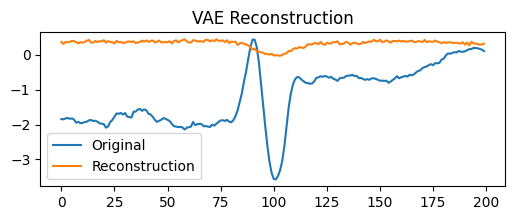

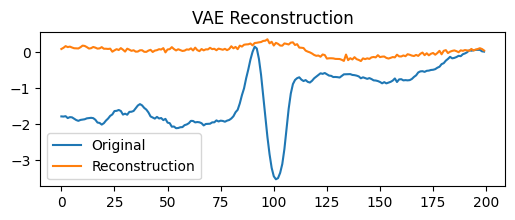

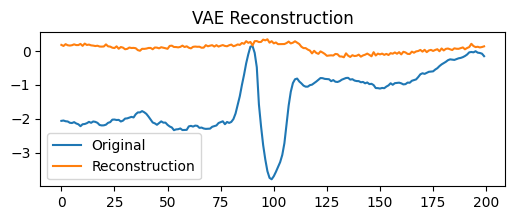

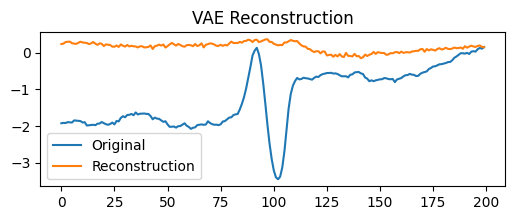

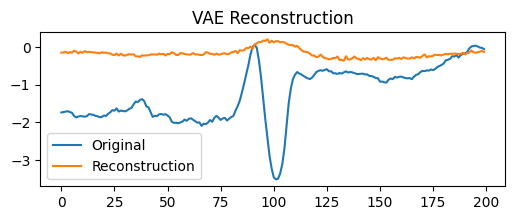

In [22]:
import matplotlib.pyplot as plt
with torch.no_grad():

    subset = X_test_t[:5]
    recon, _, _ = model(subset)

    for i in range(len(subset)):

        plt.figure(figsize=(6,2))

        plt.plot(subset[i].cpu(), label="Original")
        plt.plot(recon[i].cpu(), label="Reconstruction")

        plt.legend()
        plt.title("VAE Reconstruction")
        plt.show()


# MAE

In [23]:
import torch

import torch

def mask_signal(x, mask_ratio=0.3):
    """
    x: (batch, signal_length)

    Returns
    x_masked: masked signal
    mask: boolean mask of masked region
    """

    B, L = x.shape
    mask_len = int(L * mask_ratio)

    mask = torch.zeros(B, L, dtype=torch.bool, device=x.device)
    x_masked = x.clone()

    for i in range(B):

        start = torch.randint(0, L - mask_len + 1, (1,)).item()
        end = start + mask_len

        mask[i, start:end] = True
        x_masked[i, start:end] = 0.0

    return x_masked, mask

In [24]:
import torch.nn as nn

class ECG_MAE(nn.Module):

    def __init__(self, input_dim=200, hidden_dim=128, latent_dim=64):
        super().__init__()

        # encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
            nn.ReLU()
        )

        # decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x_masked):
        z = self.encoder(x_masked)
        recon = self.decoder(z)
        return recon, z

In [25]:
def mae_loss(recon, original, mask):
    
    diff = (recon - original) ** 2
    
    masked_loss = diff[mask]
    
    return masked_loss.mean()

In [26]:
model = ECG_MAE()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 200

for epoch in range(epochs):

    model.train()
    
    x_masked, mask = mask_signal(X_train_t, mask_ratio=0.6)
    
    recon, z = model(x_masked)

    loss = mae_loss(recon, X_train_t, mask)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(epoch, loss.item())

with torch.no_grad():
    
    Z_train = model.encoder(X_train_t).cpu().numpy()
    Z_test = model.encoder(X_test_t).cpu().numpy()

0 1.0084542036056519
10 0.8351417183876038
20 0.5820667743682861
30 0.5129754543304443
40 0.47351834177970886
50 0.43665677309036255
60 0.4118873178958893
70 0.39434826374053955
80 0.37804529070854187
90 0.36704689264297485
100 0.35807904601097107
110 0.34926638007164
120 0.33914676308631897
130 0.3300919234752655
140 0.3229422867298126
150 0.3134998679161072
160 0.30792465806007385
170 0.30472564697265625
180 0.2986120283603668
190 0.2924633324146271


In [27]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import balanced_accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(Z_train, y_train)

preds = knn.predict(Z_test)

print("Balanced Accuracy:", balanced_accuracy_score(y_test, preds))

print(confusion_matrix(y_test, preds))

Balanced Accuracy: 0.38834929355726655
[[16302   399   658     1   532]
 [   68     2     2     0     1]
 [  329    16  1983     0   111]
 [  254     1   126     1     0]
 [ 1640    50     8     0   392]]


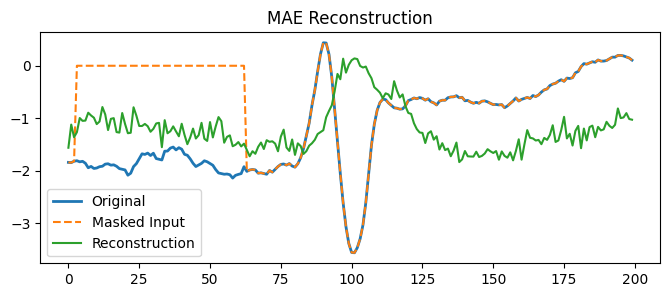

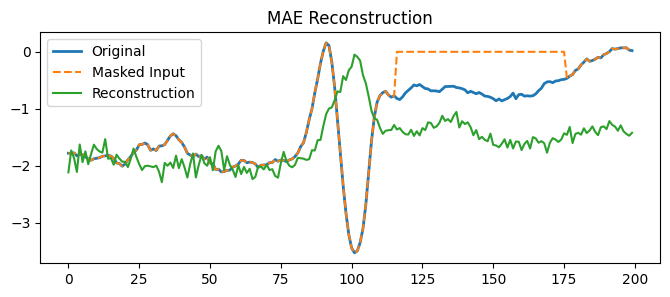

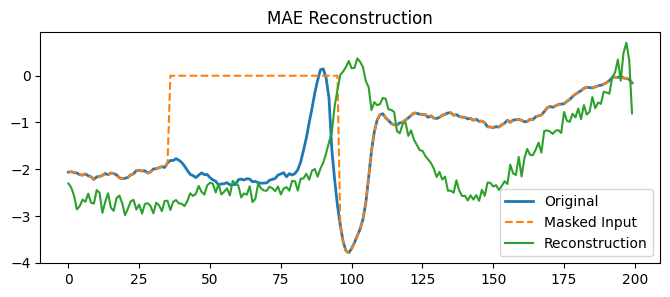

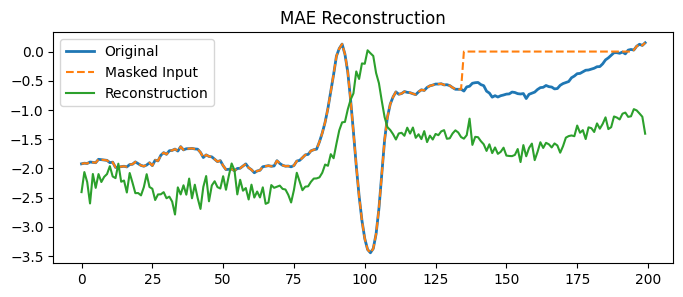

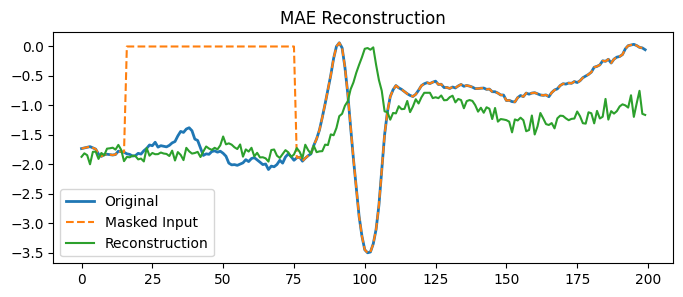

In [28]:
import matplotlib.pyplot as plt

model.eval()

with torch.no_grad():

    # take a few test beats
    subset = X_test_t[:5]

    # mask them
    x_masked, mask = mask_signal(subset, mask_ratio=0.3)

    # reconstruct
    recon, _ = model(x_masked)

    for i in range(len(subset)):

        plt.figure(figsize=(8,3))

        plt.plot(subset[i].cpu(), label="Original", linewidth=2)
        plt.plot(x_masked[i].cpu(), label="Masked Input", linestyle="dashed")
        plt.plot(recon[i].cpu(), label="Reconstruction")

        plt.title("MAE Reconstruction")
        plt.legend()
        plt.show()

# JEPA MAE

In [29]:
import torch

def sample_context_target(x, target_ratio=0.2):
    """
    x: (batch, 200)

    Returns:
    x_context: masked beat
    x_target: only target region kept
    """
    B, L = x.shape
    target_len = int(L * target_ratio)

    x_context = x.clone()
    x_target = torch.zeros_like(x)

    for i in range(B):

        start = torch.randint(0, L - target_len + 1, (1,)).item()
        end = start + target_len

        x_target[i, start:end] = x[i, start:end]
        x_context[i, start:end] = 0.0

    return x_context, x_target

In [30]:
from torch import nn
class Encoder(nn.Module):
    def __init__(self, input_dim=200, hidden_dim=64, latent_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )

    def forward(self, x):
        return self.net(x)


class Predictor(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )

    def forward(self, z):
        return self.net(z)
    
@torch.no_grad()
def update_teacher(student, teacher, momentum=0.999):

    for p_s, p_t in zip(student.parameters(), teacher.parameters()):
        p_t.data = momentum * p_t.data + (1 - momentum) * p_s.data

In [31]:
import torch.nn.functional as F

import torch.nn.functional as F

student = Encoder()
teacher = Encoder()

teacher.load_state_dict(student.state_dict())

predictor = Predictor()

optimizer = torch.optim.Adam(
    list(student.parameters()) + list(predictor.parameters()),
    lr=3e-4
)

epochs = 200
losses = []

for epoch in range(epochs):

    student.train()

    # sample context/target
    x_context, x_target = sample_context_target(X_train_t, target_ratio=0.2)

    # student encodes context
    z_context = student(x_context)

    # predictor predicts target representation
    z_pred = predictor(z_context)

    # teacher encodes target region
    with torch.no_grad():
        z_target = teacher(x_target)

    # normalize embeddings
    z_pred = F.normalize(z_pred, dim=-1)
    z_target = F.normalize(z_target, dim=-1)

    # JEPA loss
    loss = ((z_pred - z_target) ** 2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # update teacher
    update_teacher(student, teacher, momentum=0.999)

    losses.append(loss.item())
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: {loss.item():.4f}")

with torch.no_grad():

    Z_train = student(X_train_t).cpu().numpy()
    Z_test = student(X_test_t).cpu().numpy()

Epoch 0: 0.0640
Epoch 10: 0.0469
Epoch 20: 0.0340
Epoch 30: 0.0252
Epoch 40: 0.0198
Epoch 50: 0.0167
Epoch 60: 0.0148
Epoch 70: 0.0136
Epoch 80: 0.0128
Epoch 90: 0.0123
Epoch 100: 0.0119
Epoch 110: 0.0117
Epoch 120: 0.0114
Epoch 130: 0.0111
Epoch 140: 0.0109
Epoch 150: 0.0106
Epoch 160: 0.0103
Epoch 170: 0.0100
Epoch 180: 0.0097
Epoch 190: 0.0094


In [32]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(Z_train, y_train)

preds = knn.predict(Z_test)

print("Balanced accuracy:", balanced_accuracy_score(y_test, preds))
print(confusion_matrix(y_test, preds))

Balanced accuracy: 0.4499993262726273
[[16767   238   683     1   203]
 [   69     2     2     0     0]
 [  259    15  2120     1    44]
 [  245     0   132     0     5]
 [  993   221     6     0   870]]
